In [1]:
! pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf


  Using cached langchain-1.3.4-py3-none-any.whl.metadata (5.8 kB)
  Using cached langchain_openai-1.2.2-py3-none-any.whl.metadata (3.1 kB)
  Using cached faiss_cpu-1.14.2-cp314-cp314-win_amd64.whl.metadata (7.8 kB)
  Using cached langgraph-1.2.4-py3-none-any.whl.metadata (8.0 kB)
  Using cached langgraph_sdk-0.4.2-py3-none-any.whl.metadata (3.6 kB)
  Using cached websockets-15.0.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached tiktoken-0.13.0-cp314-cp314-win_amd64.whl.metadata (6.8 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached jiter-0.15.0-cp314-cp314-win_amd64.whl.metadata (5.3 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached regex-2026.5.9-cp314-cp314-win_amd64.whl.metadata (41 kB)
Using cached langchain-1.3.4-py3-none-any.whl (125 kB)
Using cached langgraph-1.2.4-py3-none-any.whl (245 kB)
Using cached langgraph_sdk-0.4.2-py3-none-any.whl (160 kB)
Using cached websockets-15.0.1-py3-none-any.whl (169 kB)
Using ca


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from langchain_ollama import ChatOllama, OllamaEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [4]:
llm = ChatOllama(model='llama3')

In [7]:
loader = PyPDFLoader("C:\Programs12\AI_Labs\AI-Labs\Week-6\Day-6\ML-Learning .pdf")
docs = loader.load()

<>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\JayaramakrishnaMedis\AppData\Local\Temp\ipykernel_1312\192675312.py:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  loader = PyPDFLoader("C:\Programs12\AI_Labs\AI-Labs\Week-6\Day-6\ML-Learning .pdf")


In [8]:
len(docs)

62

In [9]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [10]:
len(chunks)

159

In [11]:
embeddings = OllamaEmbeddings(model='llama3')
vector_store = FAISS.from_documents(chunks, embeddings)

In [ ]:
vector_store

In [ ]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [ ]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [ ]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [ ]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [ ]:
tool_node = ToolNode(tools)

In [ ]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

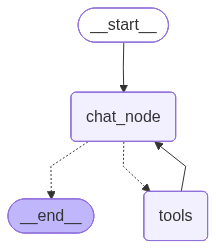

In [ ]:
chatbot

In [ ]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to find the ideal value of K in KNN"
                )
            )
        ]
    }
)

In [ ]:
print(result['messages'][-1].content)

To find the ideal value of \( K \) in the k-nearest neighbors (k-NN) algorithm, follow these steps:

1. **Understand the Role of \( K \)**: The parameter \( K \) represents the number of nearest neighbors to consider when making predictions. A small \( K \) can lead to a model that is sensitive to noise in the data, whereas a large \( K \) can smooth out the decision boundary too much, potentially leading to underfitting.

2. **Choose a Parameter Selection Method**: The most common method for selecting the ideal \( K \) is through grid search, which involves trying a range of values for \( K \) and evaluating their performance. You can use cross-validation to assess the performance of each \( K \).

3. **Set Up Cross-Validation**: Divide your dataset into training and testing subsets, and then perform k-fold cross-validation. This involves splitting the training set into \( K \) smaller sets. For each unique group, you will:
   - Train your model using the other \( K - 1 \) sets.
   - 